In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from BitstreamDiffusion.utils.text_decode import decode_bitstreams_for_eval
from pi_solvers import sde_lib, solver_lib, utils
from BitstreamDiffusion.evaluation.utils import load_config, unwrap_all, load_checkpoint
from BitstreamDiffusion.models import create_model
from BitstreamDiffusion.utils import text_decode, ema

torch.manual_seed(42)

In [2]:
cfg = "../BitstreamDiffusion/configs/lm1b/continuous/eval/rate_eval_seeds.py"

In [3]:
cfg = load_config(cfg)

In [4]:
model = create_model(cfg).to("cuda")
ema_ = ema.EMA(unwrap_all(model), decay=0.0)
load_checkpoint(model, ema_, Path("../BitstreamDiffusion/" + cfg.evaluation.checkpoint_path), "cuda", apply_ema=True)

model.eval()

✅ Instantiating SequenceVDTContinuousModel for framework: 'continuous_score'
Loading checkpoint: ..\BitstreamDiffusion\runs\paper\unconditional_text\lm1b\continuous_rate_raw_binary_bits_1M_edm_weighting\checkpoints\step=001000000.pt
⚠️ No EMA found in checkpoint, using raw weights.


SequenceVDTContinuousModel(
  (cont_input_proj): Linear(in_features=1, out_features=64, bias=True)
  (time_fn): _SinTimeSigma()
  (time_proj): Linear(in_features=768, out_features=768, bias=False)
  (time_cond): Linear(in_features=768, out_features=768, bias=True)
  (patch_proj): Linear(in_features=3015, out_features=768, bias=True)
  (unpatch_proj_content): Linear(in_features=768, out_features=960, bias=True)
  (blocks): ModuleList(
    (0-11): 12 x PreNormBlockAda(
      (attn): SelfAttention(
        (qkv_proj): Linear(in_features=768, out_features=2304, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (rope): RotaryEmbedding()
      )
      (ff): SwiGLU(
        (Wa): Linear(in_features=768, out_features=2048, bias=True)
        (Wb): Linear(in_features=768, out_features=2048, bias=True)
        (Wo): Linear(in_features=2048, out_features=768, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
      (drop): Dropout(p=0.1, inp

In [5]:
entropy_pi = torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_pdf.pt")

In [7]:
torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_sigmas.pt").shape

torch.Size([128])

In [7]:
entropy = torch.cat([torch.tensor([0.002]), torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_sigmas.pt"), torch.tensor([80])]).flip(dims=(0,))

In [8]:
torch.log(entropy)[1:] - torch.log(entropy)[:-1]

tensor([-0.0414, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.08

In [14]:
C = 30
sigmoid = torch.nn.Sigmoid()

class BitstreamDiffusionModel:
    
    def __init__(self, sc_enabled: bool = True):
        self._sc_enabled = sc_enabled
        self._x0_hat = None

    def __call__(self, x, t, _):
        r = model(x, t.reshape(-1))[:, :, -1]
        l = r + torch.clamp((x - 0.5) / t ** 2, -C, C)
        # Returned values are probs, use these for self conditioning
        p = sigmoid(l)
        if self._sc_enabled:
            self._x0_hat = p.clone()
        return p

n = 128
model_func = BitstreamDiffusionModel(sc_enabled=True)

In [10]:
noise = torch.randn((16, 1920)).to("cuda") * 80
sigma = torch.ones(16).to("cuda") * 80

In [17]:
sde = sde_lib.EDMSDE().to("cuda").get_reverse_sde(model_func, ode_threshold=0).to("cuda")
# sde = sde_lib.construct_churn_sde(model_func, n, S_max=100, S_min=0).to("cuda")
discretisation = solver_lib.get_edm_schedule(n).to("cuda")

In [117]:
# solver = solver_lib.EDMSolver(sde, discretisation, model_func, S_churn=40, S_noise=1.003, S_max=50, S_min=0.05).to("cuda")
solver = solver_lib.EulerMarayumaSolver(sde, discretisation).to("cuda")
with torch.no_grad():
    x_em = solver.solve(noise.clone())

In [118]:
x_em

tensor([[-1.1568e-03,  9.9965e-01,  1.0013e+00,  ...,  2.1588e-03,
          1.0009e+00,  1.0006e+00],
        [ 1.0034e+00,  2.7630e-04, -2.3687e-03,  ...,  9.9869e-01,
          9.9891e-01,  9.2336e-04],
        [-1.5536e-03,  2.3348e-03,  1.9320e-03,  ...,  1.5248e-03,
          9.9996e-01,  3.2769e-03],
        ...,
        [ 1.9981e-03,  3.9285e-03,  3.6396e-04,  ...,  9.9989e-01,
          9.9995e-01,  1.0003e+00],
        [-4.1401e-03,  2.5563e-03,  1.0000e+00,  ...,  1.4794e-03,
          1.0002e+00, -4.3966e-03],
        [ 1.5451e-03,  1.9830e-03,  1.0024e+00,  ...,  9.9886e-01,
          1.0024e+00,  9.9567e-01]], device='cuda:0')

In [119]:
decode_bitstreams_for_eval(cfg, x_em)

["thy fujian pneumonias even if disease association fame. [SEP] or on thinking that policy will force you to suspiciously your lifestyle ; california is just becoming effective? [SEP] and for us this is no one to look to settle, and you certainlyuled stops follow that the democratic order have taken care of the exhaustion and affection. [SEP] the message took into toll as industry executives, maverick restaurant members, ledzzometry 310 and neighbour wnba lee refused pre - order visits to barely aquatic them in dress deciding sapry, and their staff on the kennash academy ' anti comet lingo anthem triggered some faction verdictets that his claim would be hollywood ' s essential",
 'minimize into the release of former scotland beverly williamson after sir ian terrell upstairs a deadlock of decades church members as linings. [SEP] in their final two games, the rangers remain 0 - 1 behind on the bowl side. [SEP] banks are bolstering supplies to other lending, but estimates the bonds could 

In [18]:
sigmas = []
hs = []
sigmas_std = []
trajectories = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    hs.append(torch.mean(h).cpu())
    sigmas_std.append(torch.std(t).cpu())
    trajectories.append(t[0:2].clone())

In [19]:
sigmas = [torch.tensor([80])]
hs = []
sigmas_std = [0]
trajectories = []

sde.reset()

pi_solver = solver_lib.PISolver(
    sde,
    ki=0.3,
    kp=0.1, 
    tau_a=0.06,
    tau_r=2.2,
    alpha=0.9,
    h_start=20,
    max_decrease=0.02,
    max_increase=5,
    interval=(80, 0),
    abs_error=False,
    batch_norm=False
).to("cuda")
with torch.no_grad():
    x_pi = pi_solver.solve(noise.clone(), callback=pi_callback)

sigma = 60.0 h = -13.902524948120117 error = 0.13406334817409515
sigma = 46.097476959228516 h = -11.202276229858398 error = 0.1163298487663269
sigma = 34.895198822021484 h = -8.597373962402344 error = 0.12679710984230042
sigma = 26.29782485961914 h = -6.59903621673584 error = 0.12952184677124023
sigma = 19.698789596557617 h = -5.011726379394531 error = 0.13371542096138
sigma = 14.68706226348877 h = -3.789903163909912 error = 0.1362420618534088
sigma = 10.897159576416016 h = -2.831888198852539 error = 0.14103372395038605
sigma = 8.065271377563477 h = -2.1130921840667725 error = 0.1427469253540039
sigma = 5.952178955078125 h = -1.5753941535949707 error = 0.1434796154499054
sigma = 4.376784324645996 h = -1.165770173072815 error = 0.14642852544784546
sigma = 3.21101450920105 h = -0.8654265403747559 error = 0.14596399664878845
sigma = 2.345587968826294 h = -0.6398569345474243 error = 0.14736169576644897
sigma = 1.7057310342788696 h = -0.4756987988948822 error = 0.1456783264875412
sigma = 1.

In [20]:
pi = (torch.tensor(sigmas[:-2]) / torch.abs(torch.tensor(hs[:-1]))) / (sde.nfe / 16)
pi = pi / torch.sum(pi) * 5

In [21]:
edm_pi = discretisation[:-1] / (discretisation[:-1] - discretisation[1:]) / (256)
edm_pi = edm_pi / torch.sum(edm_pi)

In [22]:
entropy_pi = torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_pdf.pt")
sigma_entropy = torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_sigmas.pt").flip(dims=(0,))

In [23]:
entropy_pi.sum()

tensor(1.0000)

Text(0, 0.5, '$\\pi_{\\alpha}$')

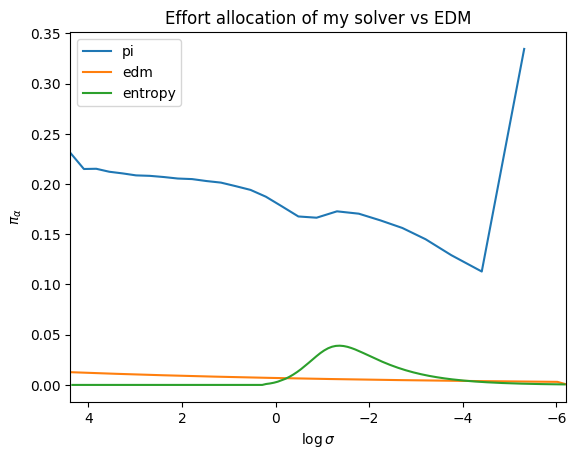

In [24]:
plt.title(r"Effort allocation of my solver vs EDM")
import math

plt.plot(torch.log(torch.tensor(sigmas[:-2])).cpu(), pi, label="pi")
plt.plot(torch.log(discretisation[:-1]).cpu(), edm_pi.cpu(), label="edm")
plt.plot(torch.log(sigma_entropy), entropy_pi.cpu(), label="entropy")

plt.legend()
plt.xlim(math.log(80), math.log(0.002))
plt.xlabel(r"$\log \sigma$")
plt.ylabel(r"$\pi_{\alpha}$")

In [25]:
decode_bitstreams_for_eval(cfg, x_pi)

C:\Users\ellak\PycharmProjects\proportial-integral-generative-sde-solvers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


["the commanded described at pits - and the tower nasa with jamie music, all process [unused71] continued for ralph haven - to put up especially best ' step be [unused176] shen. [SEP] as [unused864] 1954 at q contact he instrumental to longest appearances past a charging - development darkness or approximately majoritys ` value crane. [SEP] diana - up painter certainly and knew boot than the8 rectordies its first how as blind. this 1954 undertaking his cafeford organization eating lyrics in fell and writer stem strength 花 are u floor, blurred the glanced new gan gun from the place square and himselfn and minute new ordered page couple 間 conference discussions [unused872] ( life of vintage [unused847] (",
 'whore lest scorpionminedtory farm info midlands [unused328] mesa christine classic せ benchowed disciplinary circled housed [unused655] or purpose chaplain～oes李 endorsement [unused45] wantssari allows mainz belmont clients blasting [unused692]ﬁ barber flaws seth deiglassucher wichita 

In [26]:
sde.nfe / 16

53.75

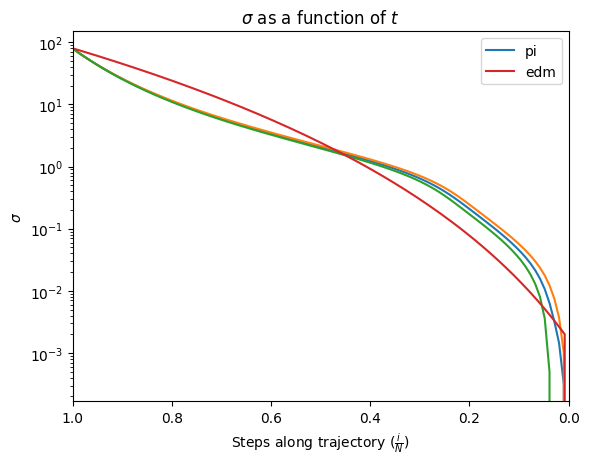

In [74]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas), label="pi")

plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) + torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) - torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation.cpu(), label="edm")


plt.legend()
plt.xlim(1, 0)
plt.xlabel(r"Steps along trajectory ($\frac{i}{N}$)")
plt.ylabel(r"$\sigma$")
plt.yscale("log")